In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chisquare, mannwhitneyu, chi2_contingency

In [22]:
hom_df = pd.read_parquet(
    "https://raw.githubusercontent.com/somsersan/AB_testing_project_1/main/homogenuity.parquet"
)
result_df = pd.read_parquet(
    "https://raw.githubusercontent.com/somsersan/AB_testing_project_1/main/result.parquet"
)
df_hom.head(3)
df_result.head(3)

,grp,user_id,bu,parent_name,subject_name,created_items_cnt,spp_pct,spp_rub,orders_rub,sales_rub,supplier_price
0,5prc_decrease,2958380FD4A91A445780DE061A44E090,Fashion,Одежда,Джинсы,3,0.301519,2259.375,5643.75,0.000,7653.125
1,5prc_decrease,233982E5C3D7464C299B00605B460E9A,Fashion,Одежда,Джинсы,4,0.357019,5888.750,10742.50,2090.000,16631.250
2,1prc_decrease,EB001560B92FD8EA77C77AAA2F2A12EA,Fashion,Одежда,Джинсы,5,0.322821,1967.500,4281.25,803.125,6085.625


In [23]:
print("result_df shape:", result_df.shape)
print("hom_df shape:", hom_df.shape)

print("\nresult_df columns:")
print(result_df.columns.tolist())

print("\nhom_df columns:")
print(hom_df.columns.tolist())

print("\nGroups in result_df:")
print(result_df["grp"].value_counts(dropna=False))

print("\nGroups in hom_df:")
print(hom_df["grp"].value_counts(dropna=False))

result_df shape: (1328879, 11)
hom_df shape: (571116, 23)

result_df columns:
['grp', 'user_id', 'bu', 'parent_name', 'subject_name', 'created_items_cnt', 'spp_pct', 'spp_rub', 'orders_rub', 'sales_rub', 'supplier_price']

hom_df columns:
['user_id', 'grp', 'bu', 'parent_name', 'subject_name', 'created_orders_cnt', 'created_items_cnt', 'created_items_rub', 'bought_items_cnt', 'bought_items_rub', 'spp_rub', 'spp_pct', 'order_days_cnt', 'aiv', 'aov', 'upt', 'age', 'gender', 'profit', 'purchase_percent', 'purchase_sum', 'locale', 'region']

Groups in result_df:
grp
5prc_decrease    201669
3prc_decrease    196417
1prc_decrease    191954
control          189717
1prc_increase    187106
3prc_increase    183368
5prc_increase    178648
Name: count, dtype: Int64

Groups in hom_df:
grp
3prc_increase    81824
5prc_decrease    81786
5prc_increase    81618
1prc_increase    81551
3prc_decrease    81516
1prc_decrease    81450
control          81371
Name: count, dtype: Int64


# SRM для `result.parquet`

In [24]:
observed_result = result_df.groupby("grp")["user_id"].count().sort_index()
expected_result = [observed_result.sum() / 7] * 7

chi2_stat_result, p_value_result = chisquare(
    f_obs=observed_result.values,
    f_exp=expected_result
)

print("SRM for result.parquet")
print(observed_result)
print("chi2 =", chi2_stat_result)
print("p-value =", p_value_result)
# Итог -> есть SRM, возможна проблема с рандомизацией

SRM for result.parquet
grp
1prc_decrease    191954
1prc_increase    187106
3prc_decrease    196417
3prc_increase    183368
5prc_decrease    201669
5prc_increase    178648
control          189717
Name: user_id, dtype: int64
chi2 = 1908.3911266563775
p-value = 0.0


# SRM для `homogenuity.parquet`

In [25]:
observed_hom = hom_df.groupby("grp")["user_id"].count().sort_index()
expected_hom = [observed_hom.sum() / 7] * 7

chi2_stat_hom, p_value_hom = chisquare(
    f_obs=observed_hom.values,
    f_exp=expected_hom
)

print("SRM for homogenuity.parquet")
print(observed_hom)
print("chi2 =", chi2_stat_hom)
print("p-value =", p_value_hom)

SRM for homogenuity.parquet
grp
1prc_decrease    81450
1prc_increase    81551
3prc_decrease    81516
3prc_increase    81824
5prc_decrease    81786
5prc_increase    81618
control          81371
Name: user_id, dtype: int64
chi2 = 2.06508310045595
p-value = 0.9136165923034071


# Подготовка метрик

In [26]:
metrics = [
    "created_orders_cnt",
    "created_items_rub",
    "bought_items_rub",
    "spp_rub",
    "order_days_cnt",
    "aov",
    "profit",
    "purchase_sum",
    "purchase_percent"
]

control_df = hom_df[hom_df["grp"] == "control"].copy()
test_groups = [g for g in hom_df["grp"].dropna().unique() if g != "control"]

print("Test groups:", test_groups)

Test groups: ['1prc_increase', '3prc_decrease', '1prc_decrease', '5prc_decrease', '5prc_increase', '3prc_increase']


# Функция для Cohen's d

In [27]:
def cohens_d(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()

    nx = len(x)
    ny = len(y)

    if nx < 2 or ny < 2:
        return np.nan

    sx = x.std(ddof=1)
    sy = y.std(ddof=1)

    pooled_std = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))

    if pooled_std == 0:
        return 0.0

    return (x.mean() - y.mean()) / pooled_std


def interpret_d(d):
    if pd.isna(d):
        return "nan"
    ad = abs(d)
    if ad < 0.1:
        return "practically no difference"
    elif ad < 0.2:
        return "very small difference"
    elif ad < 0.5:
        return "small difference"
    elif ad < 0.8:
        return "medium difference"
    else:
        return "large difference"

# Mann–Whitney U + Cohen’s d

In [29]:
results = []

for metric in metrics:
    for grp in test_groups:
        test_df = hom_df[hom_df["grp"] == grp]

        x = control_df[metric].dropna()
        y = test_df[metric].dropna()

        stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
        d = cohens_d(x, y)

        results.append({
            "metric": metric,
            "group": grp,
            "control_n": len(x),
            "test_n": len(y),
            "control_mean": x.mean(),
            "test_mean": y.mean(),
            "control_median": x.median(),
            "test_median": y.median(),
            "p_value": p_value,
            "cohens_d": d,
            "d_interpretation": interpret_d(d)
        })

balance_results = pd.DataFrame(results)
balance_results = balance_results.sort_values(["metric", "group"]).reset_index(drop=True)

balance_results.head(3)

,metric,group,control_n,test_n,control_mean,test_mean,control_median,test_median,p_value,cohens_d,d_interpretation
0,aov,1prc_decrease,81371,81450,1522.395007,1526.373375,1496.25,1503.125000,0.255899,-0.006164,practically no difference
1,aov,1prc_increase,81371,81551,1522.395007,1522.780532,1496.25,1499.193726,0.860181,-0.000600,practically no difference
2,aov,3prc_decrease,81371,81516,1522.395007,1522.883237,1496.25,1502.500000,0.484924,-0.000764,practically no difference


In [31]:
balance_results["abs_d"] = balance_results["cohens_d"].abs()

balance_results["homogeneous"] = balance_results["abs_d"] < 0.1

balance_results.head(3)

,metric,group,control_n,test_n,control_mean,test_mean,control_median,test_median,p_value,cohens_d,d_interpretation,abs_d,homogeneous
0,aov,1prc_decrease,81371,81450,1522.395007,1526.373375,1496.25,1503.125000,0.255899,-0.006164,practically no difference,0.006164,True
1,aov,1prc_increase,81371,81551,1522.395007,1522.780532,1496.25,1499.193726,0.860181,-0.000600,practically no difference,0.000600,True
2,aov,3prc_decrease,81371,81516,1522.395007,1522.883237,1496.25,1502.500000,0.484924,-0.000764,practically no difference,0.000764,True


In [39]:
balance_results.groupby("metric")["abs_d"].agg([
    "mean",
    "max"
])
balance_results["abs_d"] = balance_results["cohens_d"].abs()


### Интерпретация результатов

Для всех метрик значения Cohen's d очень малы.
Максимальное значение составляет около 0.021, что значительно меньше порога 0.1.

Это означает, что различия между контрольной и тестовыми группами
являются практически незначимыми.

Следовательно, группы можно считать однородными.

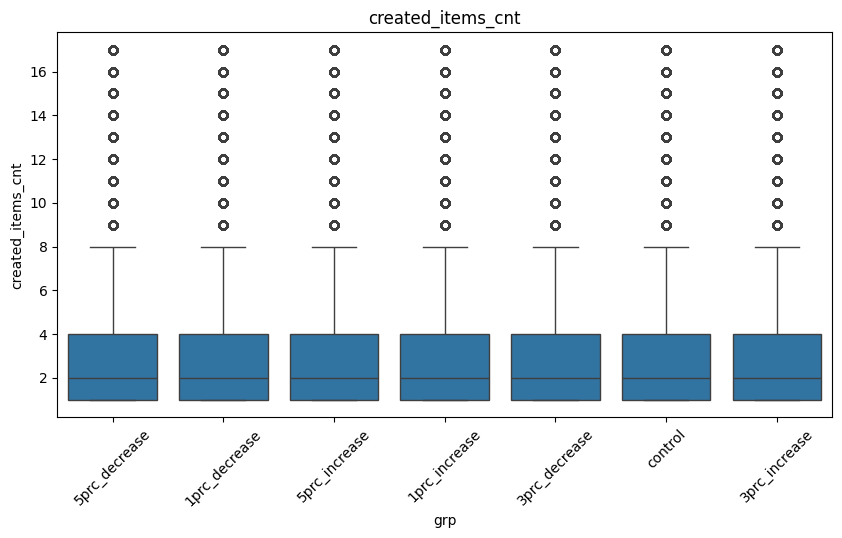

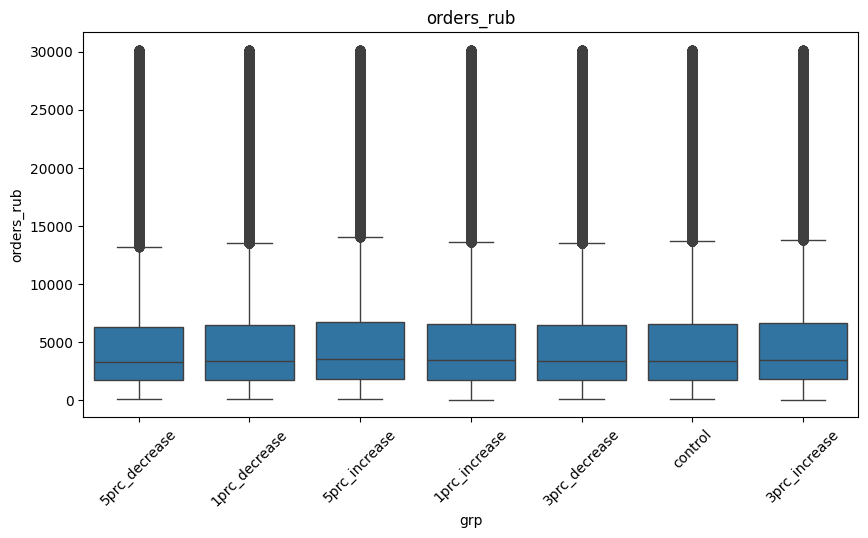

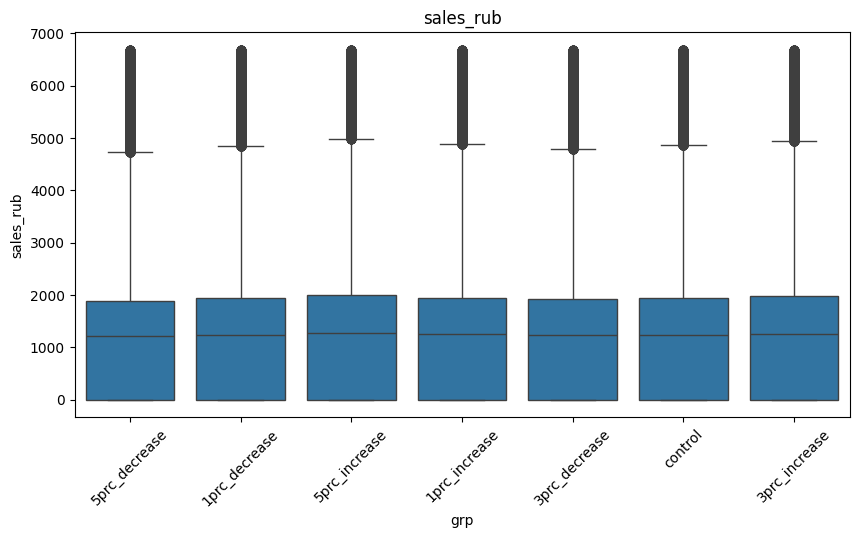

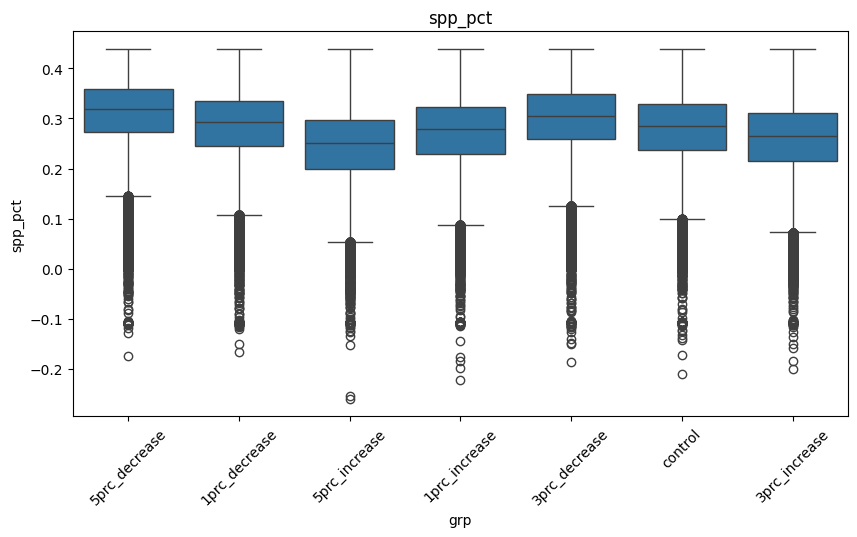

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_metrics = [
    "created_items_cnt",
    "orders_rub",
    "sales_rub",
    "spp_pct"
]

for metric in plot_metrics:

    upper = result_df[metric].quantile(0.99)

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=result_df[result_df[metric] <= upper],
        x="grp",
        y=metric
    )

    plt.xticks(rotation=45)

    plt.title(metric)

    plt.show()

# χ² тест для `locale`

In [40]:
from scipy.stats import chi2_contingency

locale_results = []

for grp in test_groups:
    subset = hom_df[hom_df["grp"].isin(["control", grp])]
    table = pd.crosstab(subset["grp"], subset["locale"])

    chi2, p, dof, exp = chi2_contingency(table)

    locale_results.append({
        "group": grp,
        "p_value": p
    })

locale_results_df = pd.DataFrame(locale_results)
locale_results_df

,group,p_value
0,1prc_increase,0.483195
1,3prc_decrease,0.618984
2,1prc_decrease,0.978938
3,5prc_decrease,0.737414
4,5prc_increase,0.811870
5,3prc_increase,0.862757


### Проверка распределения locale

Для категориальной переменной `locale` был проведён χ²-тест
между контрольной группой и каждой тестовой группой.

Во всех случаях p-value значительно превышает уровень значимости 0.05.

Это означает, что статистически значимых различий в распределении
locale между группами не обнаружено.

Следовательно, группы можно считать сбалансированными
по данной категориальной переменной.

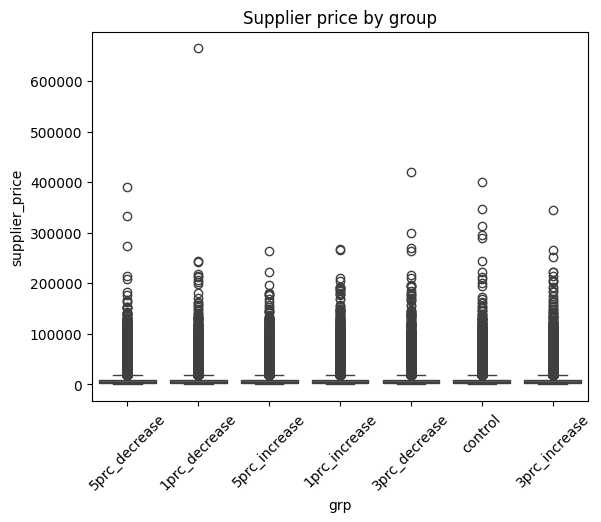

In [41]:
result_df.groupby("grp")["supplier_price"].mean()
sns.boxplot(data=result_df, x="grp", y="supplier_price")
plt.xticks(rotation=45)
plt.title("Supplier price by group")
plt.show()

## Финальный вывод

Для проверки корректности разбиения пользователей по группам
были проведены SRM-тесты, анализ баланса ковариат
и проверка категориальных признаков.

SRM-тест не выявил статистически значимого отклонения
в распределении пользователей по группам.

Анализ числовых метрик с использованием Mann–Whitney U
и оценки практической значимости через Cohen's d
показал, что различия между группами минимальны
(|Cohen's d| < 0.1).

Дополнительно проверка переменной locale
не выявила статистически значимых различий
между контрольной и тестовыми группами.

Таким образом, группы можно считать однородными,
а рандомизацию — корректной.